# Parsing_Courses_EDA_and_RegressionModels


## Импорт библиотек

In [103]:
!pip install catboost


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import scipy

from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_log_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [105]:
warnings.filterwarnings('ignore')

## Закгрузка данных

In [106]:
stepik_df = pd.read_csv('../data/stepik_courses_data.csv')
udemy_df = pd.read_csv('../data/udemy_courses_data.csv')

## Описание данных

In [107]:
stepik_df.shape

(2056, 11)

In [108]:
stepik_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2056 entries, 0 to 2055
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  2056 non-null   int64  
 1   title                  2056 non-null   object 
 2   description            2020 non-null   object 
 3   difficulty             1659 non-null   object 
 4   certificate_available  2056 non-null   object 
 5   students_count         2032 non-null   object 
 6   price                  1354 non-null   object 
 7   rating                 1562 non-null   float64
 8   reviews_count          1561 non-null   object 
 9   source                 2055 non-null   object 
 10  course                 2054 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 176.8+ KB


| №  | Название признака       | Тип данных | Количество непустых значений | Описание                                        |
| -- | ----------------------- | ---------- | ---------------------------- | ----------------------------------------------- |
| 1  | `index`                 | int64      | 2056                         | Уникальный идентификатор записи                 |
| 2  | `title`                 | object     | 2056                         | Название курса                                  |
| 3  | `description`           | object     | 2020                         | Описание курса                                  |
| 4  | `difficulty`            | object     | 1659                         | Уровень сложности курса                         |
| 5  | `certificate_available` | object     | 2056                         | Наличие сертификата по окончании курса          |
| 6  | `students_count`        | object     | 2032                         | Количество зарегистрированных студентов         |
| 7  | `price`                 | object     | 1354                         | Стоимость курса                                 |
| 8  | `rating`                | float64    | 1562                         | Средний рейтинг курса                           |
| 9  | `reviews_count`         | object     | 1561                         | Количество отзывов                              |
| 10 | `source`                | object     | 2055                         | Платформа или организация, предоставляющая курс |
| 11 | `course`                | object     | 2054                         | Категория или направление курса                 |


In [109]:
udemy_df.shape

(3443, 11)

In [110]:
udemy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3443 entries, 0 to 3442
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  3443 non-null   object 
 1   title                  3443 non-null   object 
 2   description            3442 non-null   object 
 3   difficulty             3443 non-null   object 
 4   certificate_available  3443 non-null   bool   
 5   students               3443 non-null   object 
 6   price                  3443 non-null   float64
 7   rating                 3443 non-null   object 
 8   reviews_count          3443 non-null   int64  
 9   source                 3443 non-null   object 
 10  course                 3443 non-null   object 
dtypes: bool(1), float64(1), int64(1), object(8)
memory usage: 272.5+ KB


| №  | Название признака       | Тип данных | Количество непустых значений | Описание                                        |
| -- | ----------------------- | ---------- | ---------------------------- | ----------------------------------------------- |
| 1  | `index`                 | object     | 3443                         | Уникальный идентификатор записи                 |
| 2  | `title`                 | object     | 3441                         | Название курса                                  |
| 3  | `description`           | object     | 3440                         | Описание курса                                  |
| 4  | `difficulty`            | object     | 3443                         | Уровень сложности курса                         |
| 5  | `certificate_available` | bool       | 3443                         | Наличие сертификата по окончании курса          |
| 6  | `students`              | object     | 3441                         | Количество зарегистрированных студентов         |
| 7  | `price`                 | float64    | 3443                         | Стоимость курса                                 |
| 8  | `rating`                | object     | 3443                         | Средний рейтинг курса                           |
| 9  | `reviews_count`         | object     | 3441                         | Количество отзывов                              |
| 10 | `source`                | object     | 3443                         | Платформа или организация, предоставляющая курс |
| 11 | `course`                | object     | 3443                         | Категория или направление курса                 |


## Анализ данных

### Обработка типов данных

In [111]:
stepik_df.head(2)

,index,title,description,difficulty,certificate_available,students_count,price,rating,reviews_count,source,course
0,82541,"""Поколение Python"": курс для профессионалов","Курс продолжает серию ""Поколение Python"" и рас...",Продвинутый уровень,True,15164,7900,5.0,1647,stepik,Python
1,189436,Асинхронность в Python: от новичка до эксперта,"Курс для тех, кто хочет не просто «пользоватьс...",Средний уровень,True,607,3700,5.0,16,stepik,Python


#### Stepik

In [112]:
stepik_df['difficulty'].unique()

array(['Продвинутый уровень', 'Средний уровень', 'Начальный уровень', nan,
       ' – условные алгоритмы',
       ' to learn the basic terms and the main methods of AI and ML',
       ' ассортиментом графовых систем управления базами данных'],
      dtype=object)

In [113]:
stepik_df.groupby('difficulty', dropna=False).count()

,index,title,description,certificate_available,students_count,price,rating,reviews_count,source,course
difficulty,,,,,,,,,,
to learn the basic terms and the main methods of AI and ML,1,1,1,1,0,1,1,0,0,0
ассортиментом графовых систем управления базами данных,1,1,1,1,1,1,1,0,1,1
– условные алгоритмы,1,1,1,1,1,1,0,1,1,0
Начальный уровень,1106,1106,1103,1106,1099,800,869,869,1106,1106
Продвинутый уровень,15,15,15,15,15,11,9,9,15,15
Средний уровень,535,535,532,535,535,388,434,434,535,535
NaN,397,397,367,397,381,152,248,248,397,397


In [114]:
invalid_difficulty = [
    ' – условные алгоритмы',
    ' to learn the basic terms and the main methods of AI and ML',
    ' ассортиментом графовых систем управления базами данных'
]

stepik_df = stepik_df[~stepik_df['difficulty'].isin(invalid_difficulty)]

In [115]:
stepik_df["certificate_available"].unique()

array(['True', 'False'], dtype=object)

In [116]:
stepik_df["course"].unique()

array(['Python', 'SQL', 'Программирование', 'Анализ данных и DS',
       'Веб-разработка', 'Инструменты DevOps', 'C/C++', 'Java',
       'HTML/CSS', 'JavaScript', 'Машинное обучение и наука о данных',
       'Анализ данных'], dtype=object)

In [117]:
stepik_df["source"].unique()

array(['stepik'], dtype=object)

In [118]:
# Приведение типов данных
stepik_types = {
    'title': 'string',
    'description': 'string',
    'difficulty': 'category',
    'certificate_available': 'bool',
    'students_count': 'numeric',
    'price': 'numeric',
    'rating': 'numeric',
    'reviews_count': 'numeric',
    'source': 'category',
    'course': 'category'
}

In [119]:
for col, col_type in stepik_types.items():
    if col_type == 'numeric':
        stepik_df[col] = pd.to_numeric(stepik_df[col], errors='coerce')
    elif col_type == 'category':
        stepik_df[col] = stepik_df[col].astype('category')
    elif col_type == 'bool':
        stepik_df[col] = stepik_df[col].map({'True': True, 'False': False})
    elif col_type == 'string':
        stepik_df[col] = stepik_df[col].astype(str)

In [120]:
stepik_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2053 entries, 0 to 2055
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   index                  2053 non-null   int64   
 1   title                  2053 non-null   object  
 2   description            2053 non-null   object  
 3   difficulty             1656 non-null   category
 4   certificate_available  2053 non-null   bool    
 5   students_count         2030 non-null   float64 
 6   price                  1351 non-null   float64 
 7   rating                 1560 non-null   float64 
 8   reviews_count          1560 non-null   float64 
 9   source                 2053 non-null   category
 10  course                 2053 non-null   category
dtypes: bool(1), category(3), float64(4), int64(1), object(2)
memory usage: 137.0+ KB


#### Udemy

In [121]:
udemy_df.head(2)

,index,title,description,difficulty,certificate_available,students,price,rating,reviews_count,source,course
0,datascience/,Data Science A-Z: Hands-On Exercises & ChatGPT...,Learn Data Science step by step through real A...,Все уровни,True,223 757 студента,10890.0,"4,6",34751,udemy,Обработка и анализ данных
1,machine-learning-for-absolute-beginners-level-1/,Machine Learning for Absolute Beginners - Level 1,Learn the Fundamental Concepts of Artificial I...,Начальный,True,120 723 студента,6090.0,"4,5",31061,udemy,Обработка и анализ данных


In [122]:
udemy_df['difficulty'].unique()

array(['Все уровни', 'Начальный', 'Средний', 'Профессиональный'],
      dtype=object)

In [123]:
udemy_df.groupby('difficulty', dropna = False).count()

,index,title,description,certificate_available,students,price,rating,reviews_count,source,course
difficulty,,,,,,,,,,
Все уровни,1909,1909,1909,1909,1909,1909,1909,1909,1909,1909
Начальный,964,964,964,964,964,964,964,964,964,964
Профессиональный,100,100,100,100,100,100,100,100,100,100
Средний,470,470,469,470,470,470,470,470,470,470


In [124]:
udemy_df["certificate_available"].unique()

array([ True, False])

In [125]:
udemy_df["source"].unique()

array(['udemy'], dtype=object)

In [126]:
udemy_df["course"].unique()

array(['Обработка и анализ данных'], dtype=object)

In [127]:
udemy_df['students'].unique()[:3]

array(['223\xa0757 студента', '120\xa0723 студента', '6 студента'],
      dtype=object)

In [128]:
def clean_count_students(count_student):
  if pd.isna(count_student):
      return np.nan
  count_student = count_student.split(' ')[0]
  count_student = count_student.replace('\xa0', '')
  return count_student

In [129]:
udemy_df['students'] = udemy_df['students'].apply(clean_count_students)

In [130]:
udemy_df['rating'] = udemy_df['rating'].str.replace(',', '.', regex=False)

In [131]:
udemy_df['reviews_count'].unique()[:3]

array([34751, 31061,     0])

In [132]:
udemy_df.columns

Index(['index', 'title', 'description', 'difficulty', 'certificate_available',
       'students', 'price', 'rating', 'reviews_count', 'source', 'course'],
      dtype='object')

In [133]:
# Приведение типов данных
udemy_types = {
    'title': 'string',
    'description': 'string',
    'difficulty': 'category',
    'students': 'numeric',
    'price': 'numeric',
    'rating': 'numeric',
    'reviews_count': 'numeric',
    'source': 'category',
    'course': 'category'
}

In [134]:
for col, col_type in udemy_types.items():
    if col_type == 'numeric':
        udemy_df[col] = pd.to_numeric(udemy_df[col], errors='coerce')
    elif col_type == 'category':
        udemy_df[col] = udemy_df[col].astype('category')
    elif col_type == 'string':
        udemy_df[col] = udemy_df[col].astype(str)

In [135]:
udemy_df = udemy_df.rename(columns={'students': 'students_count'})

In [136]:
udemy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3443 entries, 0 to 3442
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   index                  3443 non-null   object  
 1   title                  3443 non-null   object  
 2   description            3443 non-null   object  
 3   difficulty             3443 non-null   category
 4   certificate_available  3443 non-null   bool    
 5   students_count         3443 non-null   int64   
 6   price                  3443 non-null   float64 
 7   rating                 3443 non-null   float64 
 8   reviews_count          3443 non-null   int64   
 9   source                 3443 non-null   category
 10  course                 3443 non-null   category
dtypes: bool(1), category(3), float64(2), int64(2), object(3)
memory usage: 202.3+ KB


#### Обработка сложностей

In [137]:
# объединяем 'Все уровни' с 'Начальный'
udemy_df['difficulty'] = udemy_df['difficulty'].replace({'Все уровни': 'Начальный'})

udemy_df['difficulty'] = pd.Categorical(
    udemy_df['difficulty'],
    categories=['Начальный', 'Средний', 'Продвинутый'],
    ordered=True
)

In [138]:
stepik_df['difficulty'] = stepik_df['difficulty'].replace({
    'Начальный уровень': 'Начальный',
    'Средний уровень': 'Средний',
    'Продвинутый уровень': 'Продвинутый'
})

stepik_df['difficulty'] = pd.Categorical(
    stepik_df['difficulty'],
    categories=['Начальный', 'Средний', 'Продвинутый'],
    ordered=True
)

### Первичный статистический анализ выбросы

In [139]:
# Удаление индексов
stepik_df.drop(columns=['index'], inplace=True)
udemy_df.drop(columns=['index'], inplace=True)

In [140]:
# Дубликаты
stepik_df.duplicated().sum()

np.int64(0)

In [141]:
udemy_df.duplicated().sum()

np.int64(822)

In [142]:
udemy_df = udemy_df.drop_duplicates().reset_index(drop=True)
udemy_df.shape

(2621, 10)

In [143]:
stepik_df.describe()

,students_count,price,rating,reviews_count
count,2030.000000,1351.000000,1560.000000,1560.000000
mean,3051.183744,5191.310141,4.709744,57.079487
std,18982.775928,12218.868539,0.539351,295.666868
min,1.000000,100.000000,1.000000,1.000000
25%,38.000000,1190.000000,4.700000,2.000000
50%,180.000000,2400.000000,4.900000,8.000000
75%,909.250000,4770.000000,5.000000,27.000000
max,500137.000000,174190.000000,5.000000,5843.000000


In [144]:
udemy_df.describe()

,students_count,price,rating,reviews_count
count,2.621000e+03,2621.000000,2621.000000,2621.000000
mean,1.017909e+04,5510.144983,4.114956,870.089279
std,4.185879e+04,771.851236,1.031935,6669.085373
min,0.000000e+00,1590.000000,0.000000,0.000000
25%,1.460000e+02,5390.000000,4.100000,10.000000
50%,1.055000e+03,5390.000000,4.400000,43.000000
75%,5.799000e+03,5690.000000,4.600000,207.000000
max,1.168854e+06,13990.000000,5.000000,201336.000000


In [145]:
numeric_cols = ['students_count', 'price', 'rating', 'reviews_count']

#### Box-plot для Stepik

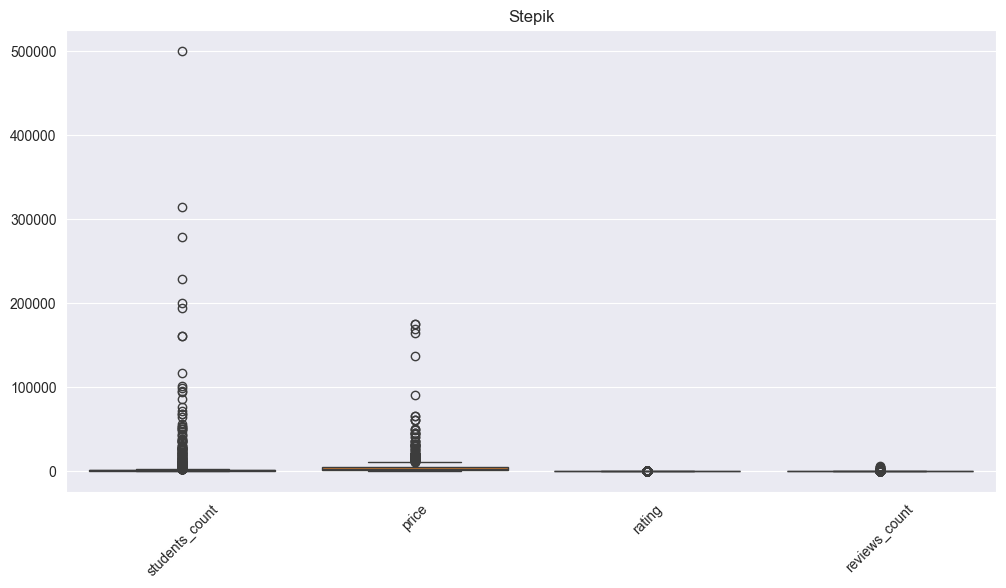

In [146]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=stepik_df[numeric_cols])
plt.title('Stepik')
plt.xticks(rotation=45)
plt.show()

#### Box-plot для Udemy

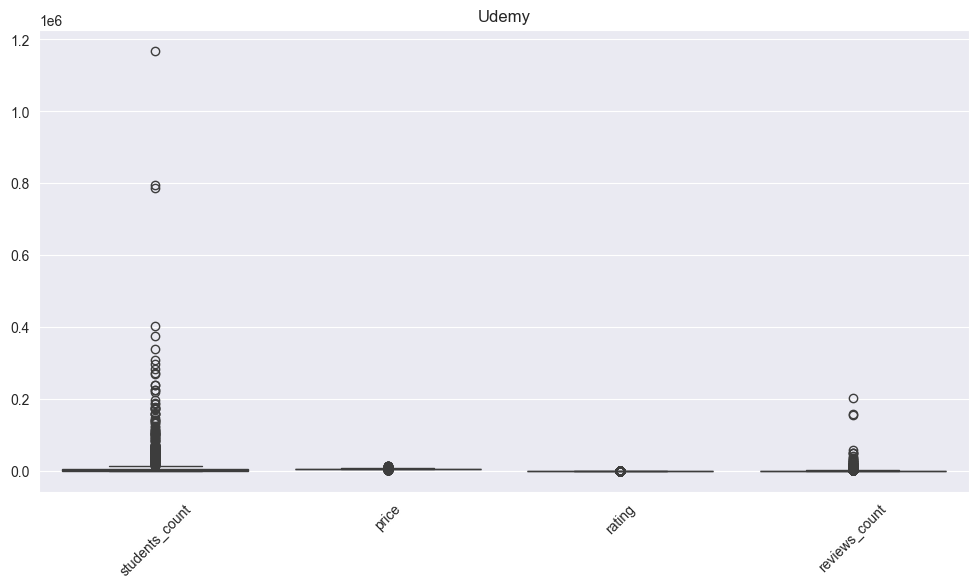

In [147]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=udemy_df[numeric_cols])
plt.title('Udemy')
plt.xticks(rotation=45)
plt.show()

## Визуальный анализ

### Матрица корреляций

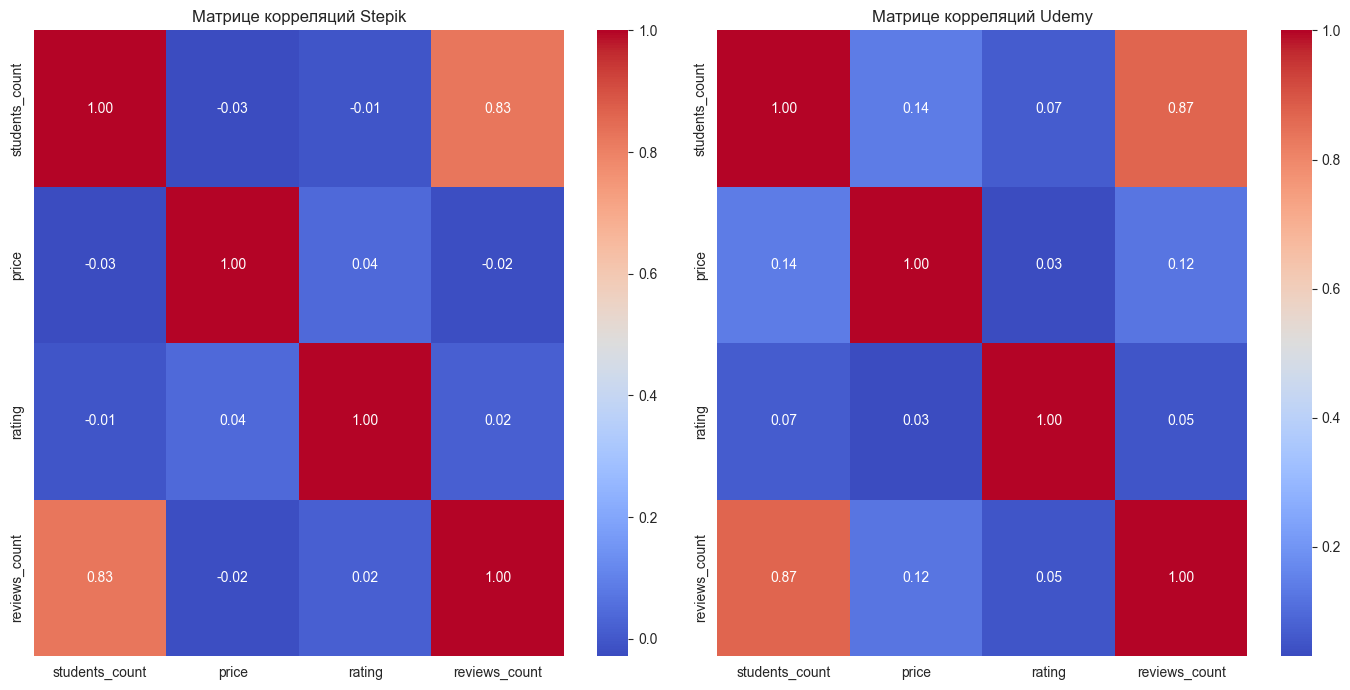

In [148]:
corr_df_stepik = stepik_df[numeric_cols].corr()
corr_df_udemy = udemy_df[numeric_cols].corr()

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.heatmap(corr_df_stepik, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Матрице корреляций Stepik")

plt.subplot(1, 2, 2)
sns.heatmap(corr_df_udemy, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Матрице корреляций Udemy")

plt.tight_layout()
plt.show()


Кол-во студентов сильно зависит от кол-во отзывов

### Гистограмма распределение кол-ва студентов Stepik

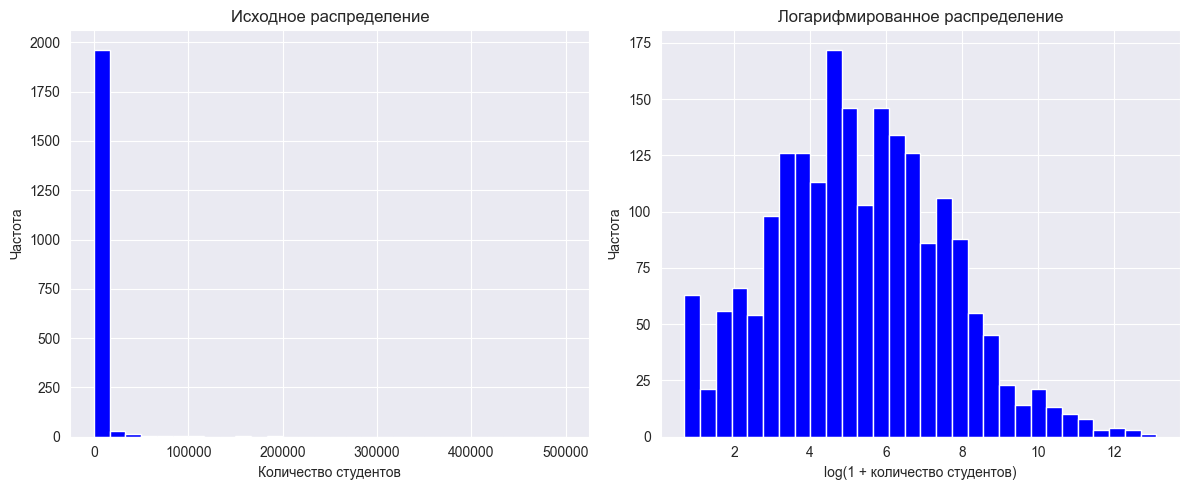

In [149]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(stepik_df['students_count'].dropna(), bins=30, color='blue')
plt.xlabel('Количество студентов')
plt.ylabel('Частота')
plt.title('Исходное распределение')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(stepik_df['students_count'].dropna()), bins=30, color='blue')
plt.xlabel('log(1 + количество студентов)')
plt.ylabel('Частота')
plt.title('Логарифмированное распределение')

plt.tight_layout()
plt.show()

Подавляющее большинство курсов имеют очень малое количество студентов

### Гистограмма распределение кол-ва студентов Udemy

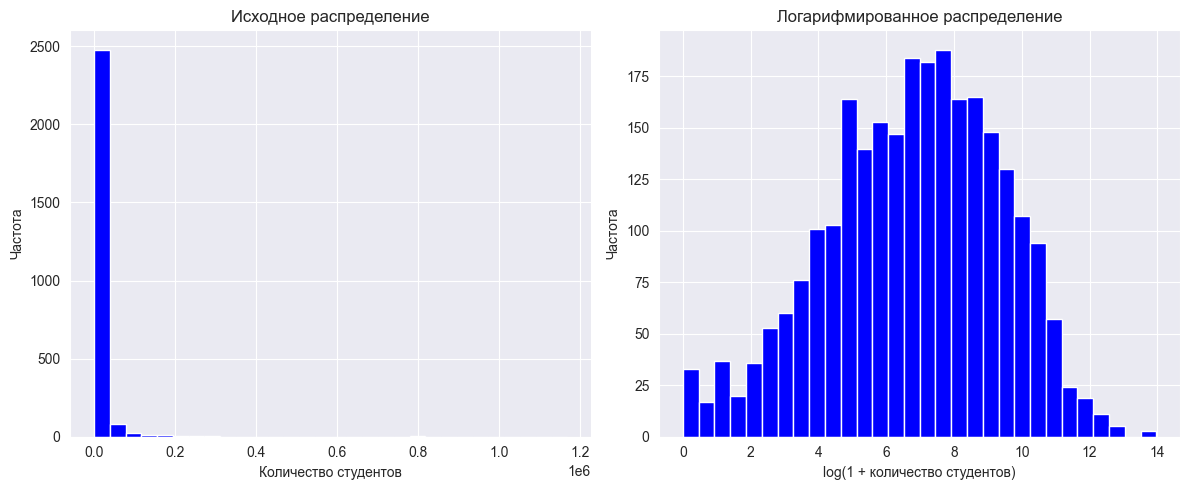

In [150]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(udemy_df['students_count'].dropna(), bins=30, color='blue')
plt.xlabel('Количество студентов')
plt.ylabel('Частота')
plt.title('Исходное распределение')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(udemy_df['students_count'].dropna()), bins=30, color='blue')
plt.xlabel('log(1 + количество студентов)')
plt.ylabel('Частота')
plt.title('Логарифмированное распределение')

plt.tight_layout()
plt.show()

Подавляющее большинство курсов имеют очень малое количество студентов

In [151]:
print(stepik_df.shape)
print(stepik_df[stepik_df['students_count'] <= 10].shape)

(2053, 10)
(222, 10)


In [152]:
print(udemy_df.shape)
print(udemy_df[udemy_df['students_count'] <= 10].shape)

(2621, 10)
(159, 10)


### Зависимость кол-ва студентов от цены на курс

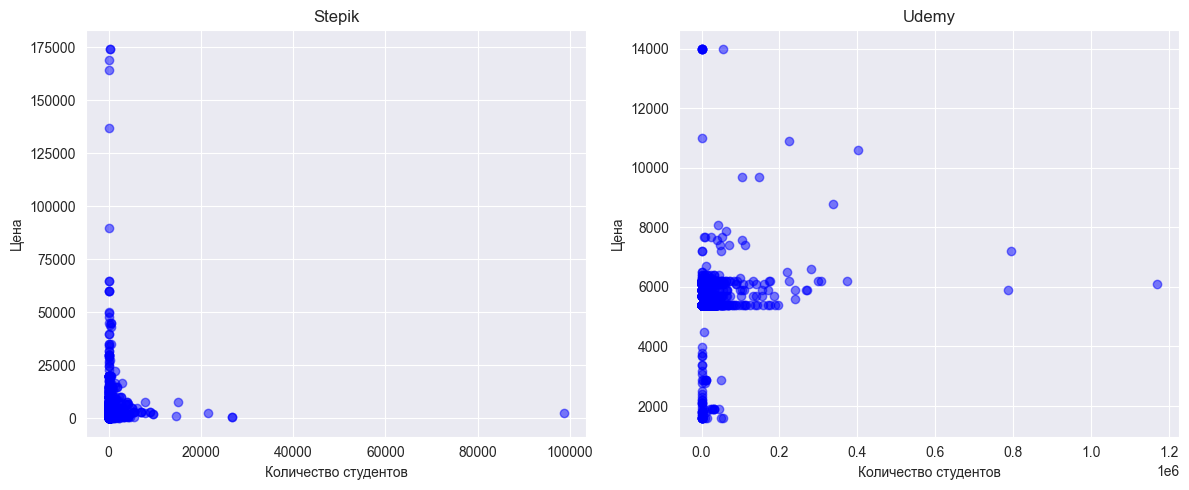

In [153]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    stepik_df['students_count'],
    stepik_df['price'],
    alpha=0.5,
    color='blue'
)
plt.xlabel('Количество студентов')
plt.ylabel('Цена')
plt.title('Stepik')

plt.subplot(1, 2, 2)
plt.scatter(
    udemy_df['students_count'],
    udemy_df['price'],
    alpha=0.5,
    color='blue'
)
plt.xlabel('Количество студентов')
plt.ylabel('Цена')
plt.title('Udemy')

plt.tight_layout()
plt.show()


### Кол-во студентов по сложностям

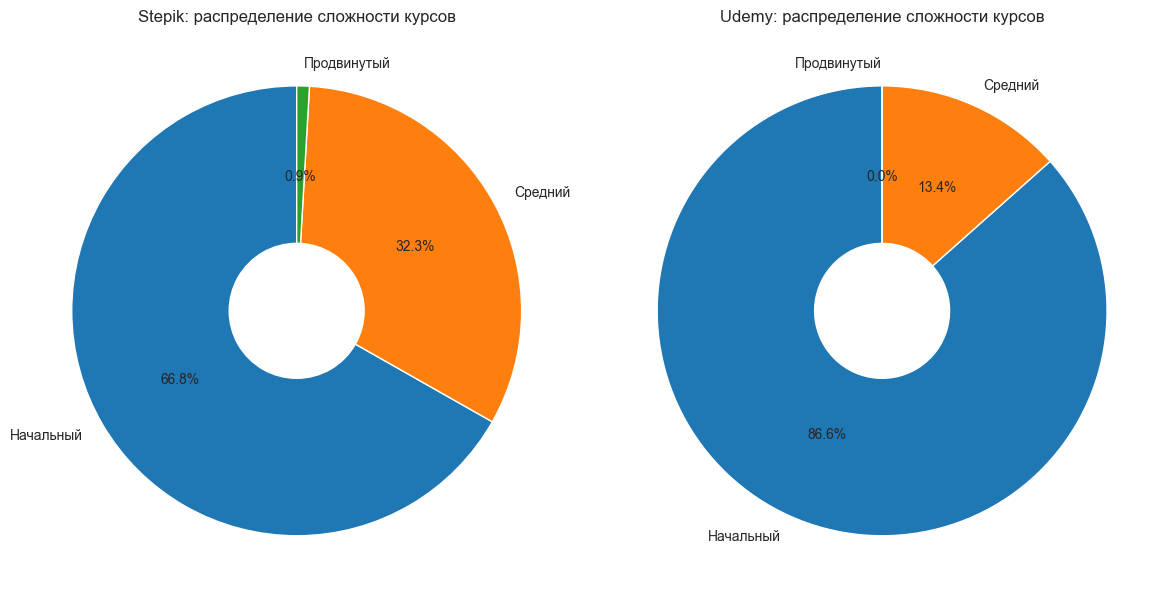

In [154]:
difficulty_counts_stepik = stepik_df['difficulty'].value_counts()
difficulty_counts_udemy = udemy_df['difficulty'].value_counts()

plt.figure(figsize=(12, 6))

# Stepik
plt.subplot(1, 2, 1)
plt.pie(
    difficulty_counts_stepik,
    labels=difficulty_counts_stepik.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.7}
)
plt.title('Stepik: распределение сложности курсов')

# Udemy
plt.subplot(1, 2, 2)
plt.pie(
    difficulty_counts_udemy,
    labels=difficulty_counts_udemy.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.7}
)
plt.title('Udemy: распределение сложности курсов')

plt.tight_layout()
plt.show()

## Обработка датасета

In [155]:
stepik_df.shape

(2053, 10)

In [156]:
udemy_df.shape

(2621, 10)

### Обработка пропусков

#### Stepik

In [157]:
stepik_df.isna().sum()

title                      0
description                0
difficulty               397
certificate_available      0
students_count            23
price                    702
rating                   493
reviews_count            493
source                     0
course                     0
dtype: int64

Пропуски в кол-ве студентов - нужно удалять

Пропуски в цене - это бесплатные курсы

Есть курсы, для которых нет рейтинга(https://stepik.org/course/223755)

Сложность можно заполнить - начальным уровнем

In [158]:
stepik_df = stepik_df.dropna(subset=['students_count']).reset_index(drop=True)

stepik_df['price'] = stepik_df['price'].fillna(0)

stepik_df['difficulty'] = stepik_df['difficulty'].fillna('Начальный')

stepik_df['rating'] = stepik_df['rating'].fillna(stepik_df['rating'].median())
stepik_df['reviews_count'] = stepik_df['reviews_count'].fillna(stepik_df['reviews_count'].median())

#### Udemy

In [159]:
udemy_df.isna().sum()

title                     0
description               0
difficulty               81
certificate_available     0
students_count            0
price                     0
rating                    0
reviews_count             0
source                    0
course                    0
dtype: int64

Также сложность заполняем - начальным уровнем

In [160]:
udemy_df['difficulty'] = udemy_df['difficulty'].fillna('Начальный')

### Обработка выбросов

In [161]:
stepik_df.shape

(2030, 10)

#### Stepik

In [162]:
iso = IsolationForest(random_state=42)
stepik_df['anomaly'] = iso.fit_predict(stepik_df[numeric_cols])
stepik_df = stepik_df[stepik_df['anomaly'] == 1]

stepik_df = stepik_df.drop(columns=['anomaly']).reset_index(drop=True)
stepik_df.shape

(1894, 10)

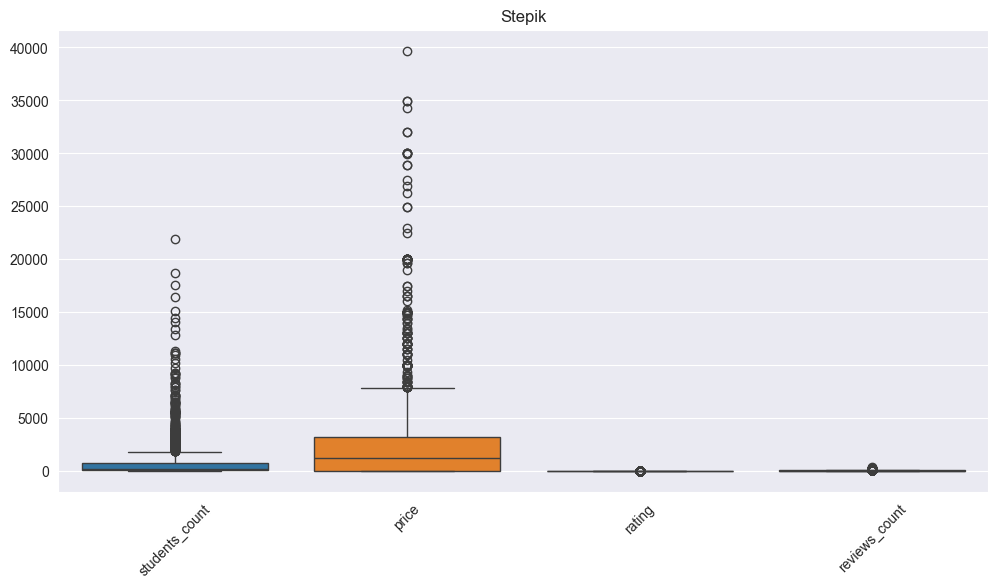

In [163]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=stepik_df[numeric_cols])
plt.title('Stepik')
plt.xticks(rotation=45)
plt.show()

#### Udemy

In [164]:
udemy_df.shape

(2621, 10)

In [165]:
iso = IsolationForest(random_state=42)
udemy_df['anomaly'] = iso.fit_predict(udemy_df[numeric_cols])
udemy_df = udemy_df[udemy_df['anomaly'] == 1]

udemy_df = udemy_df.drop(columns=['anomaly']).reset_index(drop=True)
udemy_df.shape

(2358, 10)

In [166]:
stepik_df.shape

(1894, 10)

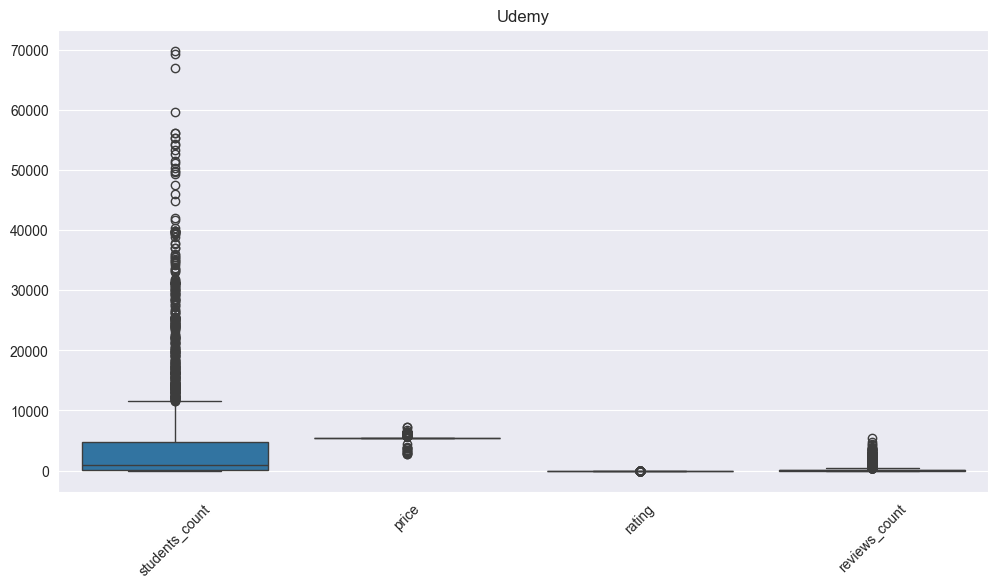

In [167]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=udemy_df[numeric_cols])
plt.title('Udemy')
plt.xticks(rotation=45)
plt.show()

### Нормализация

#### Нормализация отдельно для рейтинга

Так как для stepik минимальный рейтинг - 1, а для udemy - 0, нормализуем отдельно

In [168]:
stepik_df['rating_norm'] = (stepik_df['rating'] - 1) / 4
udemy_df['rating_norm'] = udemy_df['rating'] / 5

In [169]:
stepik_df.drop(columns=['rating'], inplace=True)
udemy_df.drop(columns=['rating'], inplace=True)

In [170]:
stepik_df.describe()

,students_count,price,reviews_count,rating_norm
count,1894.000000,1894.000000,1894.000000,1894.000000
mean,851.069694,2653.839493,17.882260,0.947782
std,1855.306034,4506.273135,32.303915,0.092618
min,1.000000,0.000000,1.000000,0.500000
25%,37.000000,0.000000,3.000000,0.950000
50%,158.000000,1200.000000,8.000000,0.975000
75%,760.000000,3150.000000,14.000000,1.000000
max,21889.000000,39700.000000,371.000000,1.000000


In [171]:
udemy_df.describe()

,students_count,price,reviews_count,rating_norm
count,2358.000000,2358.000000,2358.000000,2358.000000
mean,4695.973707,5521.552163,223.696353,0.846472
std,8822.384901,318.961323,523.577638,0.150386
min,0.000000,2790.000000,0.000000,0.000000
25%,153.250000,5390.000000,11.000000,0.820000
50%,1016.500000,5390.000000,41.000000,0.880000
75%,4739.500000,5390.000000,164.000000,0.920000
max,69817.000000,7190.000000,5421.000000,1.000000


Так как будут использоваться древовидные модели, другие признаки можно не нормализовать

## Объединение датасетов

In [172]:
stepik_df.columns

Index(['title', 'description', 'difficulty', 'certificate_available',
       'students_count', 'price', 'reviews_count', 'source', 'course',
       'rating_norm'],
      dtype='object')

In [173]:
udemy_df.columns

Index(['title', 'description', 'difficulty', 'certificate_available',
       'students_count', 'price', 'reviews_count', 'source', 'course',
       'rating_norm'],
      dtype='object')

In [174]:
df = pd.concat([stepik_df, udemy_df], ignore_index=True)

In [175]:
df.shape

(4252, 10)

In [176]:
df.head()

,title,description,difficulty,certificate_available,students_count,price,reviews_count,source,course,rating_norm
0,Асинхронность в Python: от новичка до эксперта,"Курс для тех, кто хочет не просто «пользоватьс...",Средний,True,607.0,3700.0,16.0,stepik,Python,1.000
1,Полный курс Python для начинающих + ООП,Полный курс Python для начинающих с задачами. ...,Начальный,True,944.0,4790.0,36.0,stepik,Python,0.900
2,Лучший по Python,"Самый интересный курс для тех, кто хочет начат...",Начальный,False,191.0,4300.0,5.0,stepik,Python,1.000
3,Многопроцессорный Python,Курс проведёт вас от основ до эксперта в много...,Начальный,True,800.0,2900.0,26.0,stepik,Python,0.975
4,Полный Курс Python 3: от Новичка до Мастера (П...,Для начинающих и не только! Базовый + Продвину...,Начальный,True,3523.0,500.0,85.0,stepik,Python,0.950


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   title                  4252 non-null   object  
 1   description            4252 non-null   object  
 2   difficulty             4252 non-null   category
 3   certificate_available  4252 non-null   bool    
 4   students_count         4252 non-null   float64 
 5   price                  4252 non-null   float64 
 6   reviews_count          4252 non-null   float64 
 7   source                 4252 non-null   object  
 8   course                 4252 non-null   object  
 9   rating_norm            4252 non-null   float64 
dtypes: bool(1), category(1), float64(4), object(4)
memory usage: 274.3+ KB


In [178]:
df["source"] = df["source"].astype('category')
df["course"] = df["course"].astype('category')

df['certificate_code'] = df['certificate_available'].astype(int)
df.drop(columns=['certificate_available'], inplace=True)

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   title             4252 non-null   object  
 1   description       4252 non-null   object  
 2   difficulty        4252 non-null   category
 3   students_count    4252 non-null   float64 
 4   price             4252 non-null   float64 
 5   reviews_count     4252 non-null   float64 
 6   source            4252 non-null   category
 7   course            4252 non-null   category
 8   rating_norm       4252 non-null   float64 
 9   certificate_code  4252 non-null   int64   
dtypes: category(3), float64(4), int64(1), object(2)
memory usage: 246.0+ KB


## Кодирование

In [180]:
# Удаляем описание
df.drop(columns=['description'], inplace=True)

In [181]:
df['difficulty'].unique().size

3

In [182]:
df['source'].unique().size

2

In [183]:
df['course'].unique().size

13

| Column     | Encoding Type  |
| ---------- | -------------- |
| difficulty | Label Encoding |
| source     | One-Hot Encoding |
| course     | One-Hot Encoding |


In [184]:
df['difficulty'].unique()

['Средний', 'Начальный', 'Продвинутый']
Categories (3, object): ['Начальный' < 'Средний' < 'Продвинутый']

In [185]:
# Label Encoding для difficulty
difficulty_mapping = {'Начальный': 0, 'Средний': 1, 'Продвинутый': 2}
df['difficulty_code'] = df['difficulty'].map(difficulty_mapping)

# One-Hot Encoding для source и course
df_encoded = pd.get_dummies(df, columns=['source', 'course'], drop_first=False)

df_encoded = df_encoded.drop(columns=['difficulty'])
df_encoded['difficulty_code'] = df_encoded['difficulty_code'].astype(int)

### Обработка названий

In [186]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4252 entries, 0 to 4251
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   title                                      4252 non-null   object 
 1   students_count                             4252 non-null   float64
 2   price                                      4252 non-null   float64
 3   reviews_count                              4252 non-null   float64
 4   rating_norm                                4252 non-null   float64
 5   certificate_code                           4252 non-null   int64  
 6   difficulty_code                            4252 non-null   int64  
 7   source_stepik                              4252 non-null   bool   
 8   source_udemy                               4252 non-null   bool   
 9   course_C/C++                               4252 non-null   bool   
 10  course_HTML/CSS         

In [187]:
df_encoded['title'].unique()[:5]

array(['Асинхронность в Python: от новичка до эксперта',
       'Полный курс Python для начинающих + ООП', 'Лучший по Python',
       'Многопроцессорный Python',
       'Полный Курс Python 3: от Новичка до Мастера (Питон, Пайтон)'],
      dtype=object)

In [188]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()  # перевод в нижний регистр
    text = re.sub(r'[^a-zа-я0-9\s]', '', text)  # оставляем буквы, цифры, пробелы
    text = re.sub(r'\s+', ' ', text).strip()  # убираем лишние пробелы
    return text

In [189]:
df_encoded['title'] = df_encoded['title'].apply(clean_text)

In [190]:
df_encoded.head()

,title,students_count,price,reviews_count,rating_norm,certificate_code,difficulty_code,source_stepik,source_udemy,course_C/C++,...,course_JavaScript,course_Python,course_SQL,course_Анализ данных,course_Анализ данных и DS,course_Веб-разработка,course_Инструменты DevOps,course_Машинное обучение и наука о данных,course_Обработка и анализ данных,course_Программирование
0,асинхронность в python от новичка до эксперта,607.0,3700.0,16.0,1.000,1,1,True,False,False,...,False,True,False,False,False,False,False,False,False,False
1,полный курс python для начинающих ооп,944.0,4790.0,36.0,0.900,1,0,True,False,False,...,False,True,False,False,False,False,False,False,False,False
2,лучший по python,191.0,4300.0,5.0,1.000,0,0,True,False,False,...,False,True,False,False,False,False,False,False,False,False
3,многопроцессорный python,800.0,2900.0,26.0,0.975,1,0,True,False,False,...,False,True,False,False,False,False,False,False,False,False
4,полный курс python 3 от новичка до мастера пит...,3523.0,500.0,85.0,0.950,1,0,True,False,False,...,False,True,False,False,False,False,False,False,False,False


In [191]:
cv = CountVectorizer()
X_count = cv.fit_transform(df_encoded['title'])
unique_words = cv.get_feature_names_out()

print("Всего слов в названиях:", X_count.sum())
print("Уникальных слов:", len(unique_words))

Всего слов в названиях: 26370
Уникальных слов: 3839


In [192]:
X_title = csr_matrix((df_encoded.shape[0], 0))  # 0 колонок

In [193]:
# Отбираем названия
tfidf = TfidfVectorizer(max_features=500)
X_title = tfidf.fit_transform(df_encoded['title'])

In [194]:
# Числовые признаки
numeric_cols = ['price', 'rating_norm', 'reviews_count', 'difficulty_code', 'certificate_code']
X_numeric = df_encoded[numeric_cols].values

In [195]:
# Категориальные признаки
categorical_cols = [col for col in df_encoded.columns if col.startswith('source_') or col.startswith('course_')]
X_categorical = df_encoded[categorical_cols].values

In [196]:
# Объединяем TF-IDF + числовые + категориальные признаки
X_final = scipy.sparse.hstack([X_title, X_numeric, X_categorical])

In [197]:
# Целевой признак
y = df_encoded['students_count'].values

In [198]:
print("Форма признаков:", X_final.shape)
print("Целевой признак:", y.shape)

Форма признаков: (4252, 520)
Целевой признак: (4252,)


## Разделение на тренировочную/тестовую

In [199]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

## Предсказательные модели

In [200]:
# Проверяем, есть ли NaN
print(np.isnan(y_train).sum())
print(np.isnan(y_test).sum())


0
0


### RandomForestRegressor

In [201]:
model = RandomForestRegressor(
    n_estimators=100,  # число деревьев
    random_state=42,
    n_jobs=-1  # использовать все ядра CPU
)

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания
y_pred = model.predict(X_test)

# Оценка точности
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

print("RandomForestRegressor:")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

RandomForestRegressor:
MAE: 2177.3217
Mean Squared Error: 24998998.51
RMSE: 4999.90
R2 Score: 0.4774
RMSLE: 1.5110


           Feature    Importance
502  reviews_count  4.100399e-01
343  visualization  2.000714e-02
501    rating_norm  2.000613e-02
73        complete  1.713731e-02
122      exercises  1.501471e-02
..             ...           ...
275        reactjs  2.570147e-08
101        devclub  2.300104e-08
207         middle  1.181085e-08
345            vue  4.528729e-09
88         dataops  5.595098e-12

[520 rows x 2 columns]


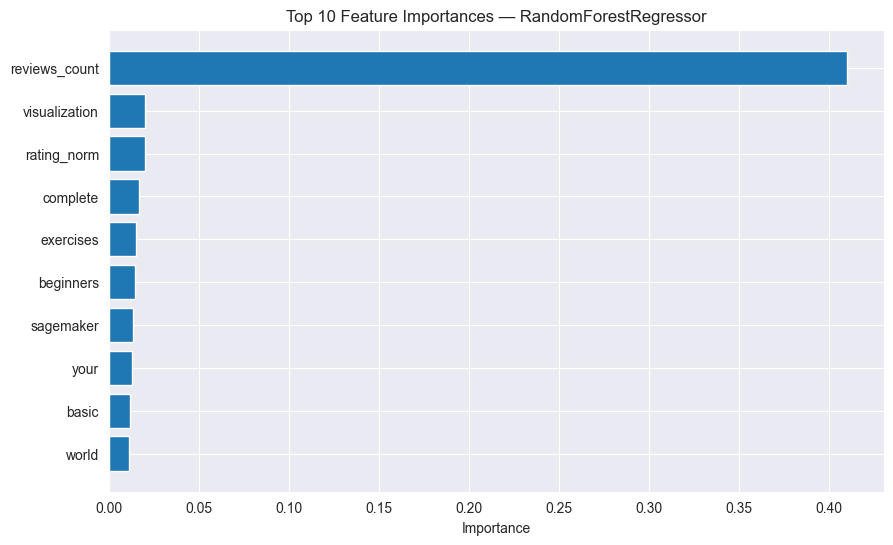

In [202]:
tfidf_features = tfidf.get_feature_names_out().tolist()

feature_names = tfidf_features + numeric_cols + categorical_cols

importances = model.feature_importances_

feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importances)

top_feat = feat_importances.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_feat['Feature'], top_feat['Importance'])
plt.gca().invert_yaxis()  # самый важный сверху
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — RandomForestRegressor")
plt.show()

plt.show()


### XGBRegressor

In [203]:
model = XGBRegressor(
    n_estimators=100,   # число деревьев
    learning_rate=0.1,  # шаг обучения
    max_depth=6,        # максимальная глубина дерева
    random_state=42,
    n_jobs=-1
)

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания
y_pred = model.predict(X_test)

# Обрезаем отрицательные и нулевые значения для RMSLE
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)
y_test_clipped = np.clip(y_test, a_min=0, a_max=None)

# Оценка точности
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, y_pred_clipped))

print("XGBRegressor:")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

XGBRegressor:
MAE: 2398.4548
Mean Squared Error: 24338093.75
RMSE: 4933.37
R2 Score: 0.4912
RMSLE: 2.0937


### LGBMRegressor (LightGBM)

In [204]:
model = LGBMRegressor(
    n_estimators=100,     # число деревьев
    learning_rate=0.1,    # шаг обучения
    max_depth=-1,         # без ограничения глубины
    random_state=42,
    n_jobs=-1
)

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания
y_pred = model.predict(X_test)

# Обрезаем отрицательные и нулевые значения для RMSLE
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)
y_test_clipped = np.clip(y_test, a_min=0, a_max=None)

# Оценка точности
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, y_pred_clipped))

print("LGBMRegressor (LightGBM):")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4980
[LightGBM] [Info] Number of data points in the train set: 3401, number of used features: 182
[LightGBM] [Info] Start training from score 2996.490444
LGBMRegressor (LightGBM):
MAE: 2350.0893
Mean Squared Error: 25733291.17
RMSE: 5072.80
R2 Score: 0.4620
RMSLE: 2.1795


### CatBoostRegressor

In [205]:
model = CatBoostRegressor(
    iterations=100,       # число деревьев
    learning_rate=0.1,    # шаг обучения
    depth=6,              # максимальная глубина дерева
    random_seed=42,
    verbose=0             # отключаем вывод процесса обучения
)

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания
y_pred = model.predict(X_test)

# Обрезаем отрицательные и нулевые значения для RMSLE
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)
y_test_clipped = np.clip(y_test, a_min=0, a_max=None)

# Оценка точности
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, y_pred_clipped))

print("CatBoostRegressor:")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

CatBoostRegressor:
MAE: 2523.5159
Mean Squared Error: 28319246.38
RMSE: 5321.58
R2 Score: 0.4080
RMSLE: 2.0725


### Stacking

In [206]:
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=-1, random_state=42, n_jobs=-1)),
    ('cat', CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_seed=42, verbose=0))
]

# Финальная мета-модель
final_model = Ridge()

# Создаём стэкинг-регрессор
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_model,
    n_jobs=-1,
    passthrough=False  # если True, исходные признаки тоже передаются финальной модели
)

stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)

# Обрезаем отрицательные и нулевые значения для RMSLE
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)
y_test_clipped = np.clip(y_test, a_min=0, a_max=None)

# Метрики
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, y_pred_clipped))

print("Stacking:")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

Stacking:
MAE: 2331.5053
Mean Squared Error: 24842803.14
RMSE: 4984.26
R2 Score: 0.4807
RMSLE: 1.9191


### GridSearch для RandomForestRegressor

In [207]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],  # число деревьев
    'max_depth': [None, 5, 10, 15, 20],         # глубина дерева
    'min_samples_split': [2, 5, 10, 15],        # мин. образцов для сплита
    'min_samples_leaf': [1, 2, 4, 6],           # мин. образцов в листе
    'max_features': ['auto', 'sqrt', 'log2']    # признаки на сплит
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                  # кросс-валидация
    n_jobs=-1,             # использовать все ядра CPU
    scoring='neg_mean_absolute_error',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшее MAE на кросс-валидации:", -grid_search.best_score_)


Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Лучшее MAE на кросс-валидации: 2609.3335510862926


Fitting 5 folds for each of 1200 candidates, totalling 6000 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Лучшее MAE на кросс-валидации: 2609.3335510862926

### RandomForestRegressor (GridSearch)

In [208]:
# Модель с лучшими параметрами
model = RandomForestRegressor(
    n_estimators=300,        # лучшее число деревьев
    max_depth=None,          # без ограничения глубины
    min_samples_split=2,     # лучший сплит
    min_samples_leaf=1,      # лучший размер листа
    max_features='sqrt',     # лучшие признаки
    random_state=42,
    n_jobs=-1
)

# Обучаем модель
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

# Для RMSLE (на всякий случай)
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)
y_test_clipped = np.clip(y_test, a_min=0, a_max=None)

# Метрики
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, y_pred_clipped))

print("RandomForestRegressor (GridSearch):")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

RandomForestRegressor (GridSearch):
MAE: 2534.9624
Mean Squared Error: 29297981.03
RMSE: 5412.76
R2 Score: 0.3875
RMSLE: 2.1016


           Feature    Importance
502  reviews_count  1.918554e-01
501    rating_norm  4.531724e-02
500          price  2.121741e-02
85            data  2.105420e-02
267         python  2.084798e-02
..             ...           ...
456          профи  5.640794e-07
435        помощью  5.539350e-07
303     sqlalchemy  4.761554e-07
283         router  4.299621e-07
88         dataops  2.117898e-07

[520 rows x 2 columns]


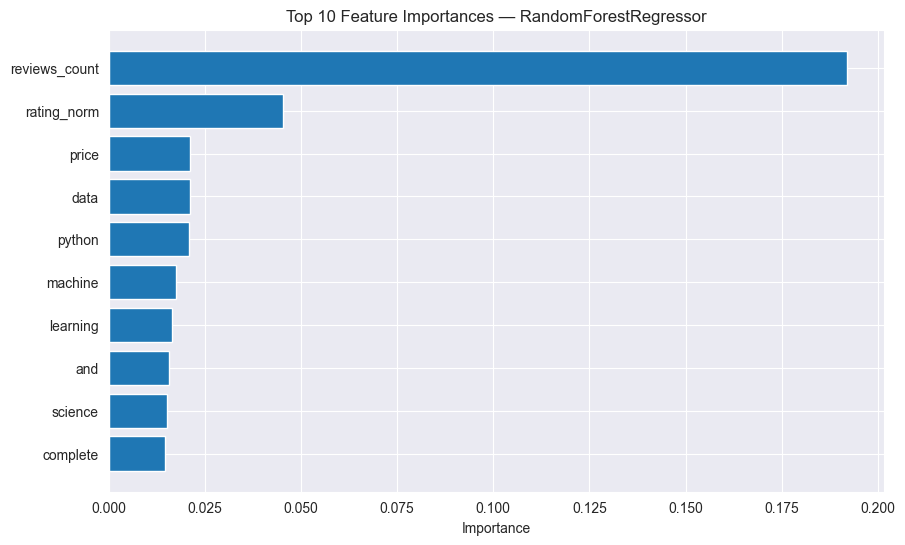

In [209]:
tfidf_features = tfidf.get_feature_names_out().tolist()

feature_names = tfidf_features + numeric_cols + categorical_cols

importances = model.feature_importances_

feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importances)

top_feat = feat_importances.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_feat['Feature'], top_feat['Importance'])
plt.gca().invert_yaxis()  # самый важный сверху
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances — RandomForestRegressor")
plt.show()

plt.show()

### GridSearch для LGBMRegressor

In [107]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],   # количество деревьев
    'max_depth': [-1, 5, 10],               # максимальная глубина (-1 = без ограничения)
    'learning_rate': [0.01, 0.05, 0.1],    # скорость обучения
    'num_leaves': [31, 50],                 # число листьев на дерево
    'min_child_samples': [20, 50],         # минимальное число объектов в листе
    'subsample': [0.8, 1.0],               # доля объектов для построения дерева
    'colsample_bytree': [0.8, 1.0]         # доля признаков для построения дерева
}

lgbm = LGBMRegressor(random_state=42, n_jobs=-1)

# GridSearch
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшее MAE на кросс-валидации:", -grid_search.best_score_)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4980
[LightGBM] [Info] Number of data points in the train set: 3401, number of used features: 182
[LightGBM] [Info] Start training from score 2996.490444
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Лучшее MAE на кросс-валидации: 2518.3044668007155

### LGBMRegressor (GridSearch)

In [109]:
model = LGBMRegressor(
    n_estimators=100,     # число деревьев
    learning_rate=0.05,    # шаг обучения
    max_depth=10,         # без ограничения глубины
    colsample_bytree=1.0,
    min_child_samples=20,
    num_leaves=31,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания
y_pred = model.predict(X_test)

# Обрезаем отрицательные и нулевые значения для RMSLE
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)
y_test_clipped = np.clip(y_test, a_min=0, a_max=None)

# Оценка точности
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, y_pred_clipped))

print("LGBMRegressor (GridSearch):")
print(f"MAE: {mae:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002419 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4980
[LightGBM] [Info] Number of data points in the train set: 3401, number of used features: 182
[LightGBM] [Info] Start training from score 2996.490444
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

## Итог

| Модель                          | MAE         | RMSE        | R²         | RMSLE      |
| ------------------------------- | ----------- | ----------- | ---------- | ---------- |
| RandomForest                    | **2177.32** | 4999.90     | 0.4774     | **1.5110** |
| XGB                             | 2398.45     | **4933.37** | **0.4912** | 2.0937     |
| LGBM                            | 2350.09     | 5072.80     | 0.4620     | 2.1795     |
| CatBoost                        | 2523.52     | 5321.58     | 0.4080     | 2.0725     |
| Stacking (RF+XGB+LGBM+CatBoost) | 2331.51     | 4984.26     | 0.4807     | 1.9191     |
| RandomForest (GridSearch)       | 2534.96     | 5412.76     | 0.3875     | 2.1016     |
| LGBM (GridSearch)               | 2315.40     | 5019.51     | 0.4733     | 1.9503     |
